In [1]:

# ============================================================
# step_01 LOAD DATA (CLEAN VERSION)
# ============================================================
# Why:
# - Load the cleaned version of the preprocessed dataset
# - Avoids synthetic leakage from rare hobby categories

from pathlib import Path
import pandas as pd
import os, random, numpy as np, pandas as pd
SEED=42; random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"]=str(SEED)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, classification_report
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"

# 🔁 Explicitly use the cleaned version of the CSV
DATA = PROC / "insurance_claims_preprocessed_no_hobbies.csv"
assert DATA.exists(), f"File not found: {DATA}"

print("Using cleaned dataset:", DATA.name)

df = pd.read_csv(DATA)
print(df.shape); df.head(2)


Using cleaned dataset: insurance_claims_preprocessed_no_hobbies.csv
(1000, 51)


,months_as_customer,age,policy_state,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,...,hour_sin,hour_cos,hour_bin_4,vehicle_age,csl_per_person,csl_per_incident,street_type,vehicle_age_bucket,vehicle_tier,body_type
0,328,48,OH,1000,1406.91,0,MALE,MD,craft-repair,husband,...,0.965926,0.258819,Night (0-5),11,250,500,Drive,old,low,other
1,228,42,IN,2000,1197.22,5000000,MALE,MD,machine-op-inspct,other-relative,...,0.866025,-0.500000,Morning (6-11),8,250,500,Hwy,old,premium,other


In [2]:
# ============================================================
# step_02 TARGET PRESENCE & LABEL SANITY
# ============================================================
# Why:
# - Guardrail: ensure label exists and is binary.
# - Fail early if the dataset is not what we expect.

assert "target" in df.columns, f"Expected 'target' in columns, got: {df.columns.tolist()}"
unique_y = set(df["target"].unique())
assert unique_y <= {0,1}, f"Labels must be binary 0/1, got: {unique_y}"
print("Labels OK →", unique_y)


Labels OK → {np.int64(0), np.int64(1)}


In [3]:
# ============================================================
# step_03 BUILD X / y
# ============================================================
# Why:
# - Separate features from label before ANY preprocessing.
# - This blocks label leakage later.

X = df.drop(columns=["target"])
y = df["target"]
print("X:", X.shape, "| y:", y.shape)


X: (1000, 50) | y: (1000,)


In [4]:
# ============================================================
# step_04 TOTAL_CLAIM_AMOUNT — NONLINEARITY EXPLORATION
# ============================================================
# Why:
# - `total_claim_amount` shows weak model importance, which is suspicious.
# - Hypothesis: the relationship with fraud is nonlinear — certain value "zones"
#   might have higher fraud rates.
# - We'll bin claim amounts into deciles (equal‑frequency bins) and visualize fraud rates.
# - Non‑monotonic behavior ⇒ nonlinearity ⇒ reason for low raw importance.

import pandas as pd
import plotly.express as px

# --- Step 1: Create quantile bins (deciles)
df["claim_decile"] = pd.qcut(df["total_claim_amount"], q=10, duplicates='drop')

# --- Step 2: Compute fraud statistics per bin
claim_bin_stats = (
    df.groupby("claim_decile", observed=True)["target"]
    .agg(['count', 'sum'])
    .reset_index()
)
claim_bin_stats["fraud_rate"] = claim_bin_stats["sum"] / claim_bin_stats["count"]

# --- Step 3: Convert Interval objects → readable strings for Plotly
claim_bin_stats["claim_decile_str"] = claim_bin_stats["claim_decile"].astype(str)

# --- Step 4: Interactive bar plot with Plotly
fig = px.bar(
    claim_bin_stats,
    x="claim_decile_str",
    y="fraud_rate",
    title="Fraud Rate by Total Claim Amount (Decile Bins)",
    labels={"claim_decile_str": "Total Claim Amount Bin", "fraud_rate": "Fraud Rate"},
)
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_tickformat=".0%",
    template="plotly_white"
)
fig.show()

# --- Optional: Inspect table for numeric verification
claim_bin_stats[["claim_decile_str", "count", "sum", "fraud_rate"]]


,claim_decile_str,count,sum,fraud_rate
0,"(99.999, 5756.0]",100,11,0.110000
1,"(5756.0, 33344.0]",100,8,0.080000
2,"(33344.0, 46842.0]",100,24,0.240000
3,"(46842.0, 53280.0]",102,28,0.274510
4,"(53280.0, 58055.0]",98,29,0.295918
5,"(58055.0, 62888.0]",100,27,0.270000
6,"(62888.0, 68012.0]",100,27,0.270000
7,"(68012.0, 74360.0]",101,38,0.376238
8,"(74360.0, 81364.0]",99,27,0.272727
9,"(81364.0, 114920.0]",100,28,0.280000


In [5]:
# ============================================================
# step_05 TOTAL_CLAIM_AMOUNT — RISK BANDING
# ============================================================
# Why:
# - We've confirmed `total_claim_amount` has a nonlinear relationship to fraud.
# - Instead of using raw or binned values directly, we convert into 3 intuitive bands:
#   'low', 'medium', 'high' risk.
# - Helps model interpretability, robustness, and interaction modeling.

def classify_claim_band(x):
    if x <= 33344:
        return "low"
    elif x <= 58055:
        return "medium"
    else:
        return "high"

# --- Create the categorical and encoded risk bands
df["claim_amount_risk_band"] = df["total_claim_amount"].apply(classify_claim_band)
risk_band_map = {"low": 0, "medium": 1, "high": 2}
df["claim_amount_risk_band_encoded"] = df["claim_amount_risk_band"].map(risk_band_map)

# --- Quick check: distribution and fraud rate by band
summary = (
    df.groupby("claim_amount_risk_band")["target"]
    .agg(['count', 'sum'])
    .assign(fraud_rate=lambda x: x['sum'] / x['count'])
)
print(summary)


                        count  sum  fraud_rate
claim_amount_risk_band                        
high                      500  147       0.294
low                       200   19       0.095
medium                    300   81       0.270


In [7]:
# ============================================================
# step_06 FEATURE ENGINEERING — CLAIM AMOUNT RISK BANDS
# ============================================================
# Why:
# - Keep engineered features isolated for testing and cleaner model pipeline.
# - Easier to debug, visualize, and reuse across experiments.
# - We only store: raw claim value, derived risk band, encoded band, and target.

# --- Define fraud risk band logic based on earlier decile fraud pattern
def classify_claim_band(x):
    if x <= 33344:
        return "low"
    elif x <= 58055:
        return "medium"
    else:
        return "high"

# --- Build new features in a separate DataFrame
df_features_claim = pd.DataFrame({
    "total_claim_amount": df["total_claim_amount"],
    "claim_amount_risk_band": df["total_claim_amount"].apply(classify_claim_band),
    "target": df["target"]  # keep for eval
})

# --- Encode the categorical risk band (optional for model input)
risk_band_map = {"low": 0, "medium": 1, "high": 2}
df_features_claim["claim_amount_risk_band_encoded"] = (
    df_features_claim["claim_amount_risk_band"].map(risk_band_map)
)

# --- Quick check
print(df_features_claim.head())


   total_claim_amount claim_amount_risk_band  target  \
0               71610                   high       1   
1                5070                    low       1   
2               34650                 medium       0   
3               63400                   high       1   
4                6500                    low       0   

   claim_amount_risk_band_encoded  
0                               2  
1                               0  
2                               1  
3                               2  
4                               0  


In [8]:
# ============================================================
# step_07 CLAIM AMOUNT RISK BAND — FINAL DECISION
# ============================================================
# What we did:
# - Investigated why `total_claim_amount` had low feature importance.
# - Discovered a nonlinear pattern in fraud rates across quantile bins (deciles).
# - Engineered a simplified categorical version: `claim_amount_risk_band`
#   → Based on fraud rate clusters: 'low', 'medium', 'high'
#
# What we tested:
# - Compared model performance using:
#   (1) decile buckets (10 categories)
#   (2) 3-level risk band (low/medium/high)
# - Cross-validated AUC scores showed:
#   → Risk bands performed better: AUC = 0.533 vs. 0.517 for deciles.
#
# Final decision:
# ✅ Keep `claim_amount_risk_band_encoded` as the final modeling feature.
# ❌ Drop decile-based version for modeling — added noise, no gain.
#
# Next steps:
# - Explore interactions with this band (e.g. high-claim & missing collision type).
# - Use this version in baseline and advanced models moving forward.



from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Prepare 2 versions of the feature
df_features_claim["claim_amount_decile"] = df["claim_decile"].astype(str)
df_features_claim["claim_amount_risk_band"] = df["claim_amount_risk_band"]

# Define models
features_riskband = ["claim_amount_risk_band"]
features_decile = ["claim_amount_decile"]

# Preprocessor for categorical (OneHot for both)
preprocessor_risk = ColumnTransformer([("cat", OneHotEncoder(), features_riskband)])
preprocessor_decile = ColumnTransformer([("cat", OneHotEncoder(), features_decile)])

# Pipelines
model_risk = Pipeline([("pre", preprocessor_risk), ("clf", RandomForestClassifier())])
model_decile = Pipeline([("pre", preprocessor_decile), ("clf", RandomForestClassifier())])

# Compare via cross-validation
scores_risk = cross_val_score(model_risk, df_features_claim[features_riskband], df_features_claim["target"], cv=5, scoring='roc_auc')
scores_decile = cross_val_score(model_decile, df_features_claim[features_decile], df_features_claim["target"], cv=5, scoring='roc_auc')

print("Risk Band AUC:", scores_risk.mean())
print("Decile AUC:", scores_decile.mean())


Risk Band AUC: 0.5334671081677704
Decile AUC: 0.5170168743523899


In [9]:
# ============================================================
# step_08 DROP DECILE BIN FEATURE (LOW VALUE)
# ============================================================
# Why:
# - We've validated that `claim_amount_decile` adds little predictive signal.
# - Risk band version is more compact, generalizable, and performs better.
# - Keeping both adds noise and redundancy.

# 🔻 Drop decile-based claim bin
if "claim_decile" in df.columns:
    df.drop(columns=["claim_decile"], inplace=True)

print("✅ Dropped decile feature — keeping only risk band version.")


✅ Dropped decile feature — keeping only risk band version.


In [10]:
# ============================================================
# step_09 COLLISION TYPE MISSING — SIGNAL VALIDATION
# ============================================================
# Why:
# - `collision_type_missing` was engineered based on the assumption that
#   fraudsters may omit collision info deliberately.
# - XGB gave it **very high importance**, Random Forest less so.
# - Let's check if this missing flag aligns with higher fraud rate.

import pandas as pd
import plotly.express as px

# --- Step 1: Aggregate fraud rate by missing flag (0 = not missing, 1 = missing)
df_features_collision = df[["collision_type_missing", "target"]].copy()
fraud_by_missing = (
    df_features_collision
    .groupby("collision_type_missing", observed=True)["target"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "fraud_count"})
    .assign(fraud_rate=lambda x: x["fraud_count"] / x["count"])
    .reset_index()
)

# --- Step 2: Human-readable labels (optional)
fraud_by_missing["missing_label"] = fraud_by_missing["collision_type_missing"].map({
    0: "Not Missing",
    1: "Missing"
})

# --- Step 3: Plot with Plotly
fig = px.bar(
    fraud_by_missing,
    x="missing_label",
    y="fraud_rate",
    title="Fraud Rate by Collision Type Missing Flag",
    labels={"missing_label": "Collision Info", "fraud_rate": "Fraud Rate"},
    text=fraud_by_missing["fraud_rate"].apply(lambda x: f"{x:.2%}")
)
fig.update_layout(template="plotly_white", yaxis_tickformat=".0%")
fig.show()

# --- Optional: view raw numbers
fraud_by_missing


,collision_type_missing,count,fraud_count,fraud_rate,missing_label
0,0,822,231,0.281022,Not Missing
1,1,178,16,0.089888,Missing


In [11]:
# ============================================================
# step_10 COLLISION TYPE MISSING — FINAL DECISION
# ============================================================
# What we found:
# - Contrary to the original assumption, missing collision type is associated
#   with **lower** fraud rates (~9%), while reported collisions show ~28% fraud.
# - So the feature is still **useful**, but the direction of signal is reversed.
# - XGBoost correctly flagged this as important — it's not leakage, it's valid signal.

# Final decision:
# ✅ Keep `collision_type_missing` — strong negative indicator for fraud.
# ❗ Update documentation / team assumptions: missingness ≠ fraud in this case.
# Optional next steps:
# - Investigate actual `collision_type` categories for deeper fraud correlations.
# - Create interaction terms: `collision_type_missing * claim_band` etc.


In [12]:
# ============================================================
# step_11 INCIDENT SEVERITY — CORRELATION + FRAUD SIGNAL
# ============================================================
# Why:
# - RF gave high weight to `incident_severity`, XGB didn't.
# - We suspect issues with dummy encoding or multicollinearity.
# - Let’s validate whether the fraud signal is strong + clean per severity level.

import pandas as pd
import plotly.express as px

# --- Step 1: Fraud rate per severity level
severity_fraud = (
    df[["incident_severity", "target"]]
    .groupby("incident_severity", observed=True)
    .agg(count=("target", "count"), frauds=("target", "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["count"])
    .reset_index()
)

# --- Step 2: Plot fraud rate per level
fig = px.bar(
    severity_fraud,
    x="incident_severity",
    y="fraud_rate",
    title="Fraud Rate by Incident Severity",
    labels={"incident_severity": "Severity", "fraud_rate": "Fraud Rate"},
    text=severity_fraud["fraud_rate"].apply(lambda x: f"{x:.2%}")
)
fig.update_layout(template="plotly_white", yaxis_tickformat=".0%")
fig.show()

# --- Optional Step 3: Check correlation between dummy columns if already encoded
# (Assumes one-hot encoded columns like `incident_severity_Major Damage`, etc.)
incident_dummy_cols = [col for col in df.columns if col.startswith("incident_severity_")]
corr_matrix = df[incident_dummy_cols].corr()
corr_matrix.style.background_gradient(cmap="coolwarm")


In [13]:
# ============================================================
# step_12 INCIDENT SEVERITY — FINAL ENCODING
# ============================================================
# What we saw:
# - 'Major Damage' has a massive fraud rate spike (60%).
# - All other classes are tightly grouped with low fraud rates (~6–13%).
# - Suggests we can collapse the feature into a binary flag.

# --- Build new flag for suspicious severity
df_features_severity = pd.DataFrame({
    "incident_severity": df["incident_severity"],
    "target": df["target"]
})

df_features_severity["incident_severity_is_major"] = (
    df_features_severity["incident_severity"] == "Major Damage"
).astype(int)

# --- Optional: evaluate impact
severity_summary = (
    df_features_severity
    .groupby("incident_severity_is_major")["target"]
    .agg(["count", "sum"])
    .assign(fraud_rate=lambda x: x["sum"] / x["count"])
)
print(severity_summary)


# ============================================================
# step_05c INCIDENT SEVERITY — FINAL DECISION
# ============================================================
# What we found:
# - 'Major Damage' incidents have extremely high fraud rates (~60%),
#   while all other categories are clustered ~11%.
# - This explains the high importance in Random Forest.
# - XGBoost likely underweights due to sparse dummy encoding.

# Final Decision:
# ✅ Keep `incident_severity_is_major` as a binary feature.
# ❌ Drop the full one-hot encoded `incident_severity_*` dummies.
#
# Why:
# - Reduces dimensionality (fewer dummy features)
# - Captures clean, interpretable fraud signal
# - Works better in trees and in production logic

# Next Steps:
# - Add this to the main engineered feature set.
# - Optionally explore interactions: e.g. `is_major_damage * high_claim`



                            count  sum  fraud_rate
incident_severity_is_major                        
0                             724   80    0.110497
1                             276  167    0.605072


In [14]:
# ============================================================
# step_13 TIME + CLAIM INTERACTION — COMPOSITE RISK FLAG
# ============================================================
# Why:
# - Time features individually are weak predictors of fraud.
# - But patterns like "high claim during weekend/holiday/evening" may be risky.
# - We'll build a composite binary flag to catch that specific behavior.

# Assumes `df_features_claim` already includes `claim_amount_risk_band_encoded`
# and df has: hour_bin_4, incident_weekend, is_holiday, holiday_window_2d

# --- Create base DataFrame for interaction features
df_features_time = pd.DataFrame({
    "hour_bin_4": df["hour_bin_4"],
    "incident_weekend": df["incident_weekend"],
    "is_holiday": df["is_holiday"],
    "holiday_window_2d": df["holiday_window_2d"],
    "claim_amount_risk_band_encoded": df["claim_amount_risk_band_encoded"],
    "target": df["target"]
})

# --- Define the composite fraud-risk time condition
# Triggers if:
# - Claim is "high risk" (encoded as 2)
# - And it occurs during one or more suspicious time buckets
df_features_time["fraud_time_window_flag"] = (
    (df_features_time["claim_amount_risk_band_encoded"] == 2) &
    (
        (df_features_time["hour_bin_4"].isin(["Evening (18-23)", "Night (0-5)"])) |
        (df_features_time["incident_weekend"] == 1) |
        (df_features_time["is_holiday"] == 1) |
        (df_features_time["holiday_window_2d"] == 1)
    )
).astype(int)

# --- Optional: Check fraud rate in vs. out of this pattern
summary = (
    df_features_time.groupby("fraud_time_window_flag")["target"]
    .agg(["count", "sum"])
    .assign(fraud_rate=lambda x: x["sum"] / x["count"])
)
print(summary)

# Decision:
# ✅ Keep `fraud_time_window_flag` in the feature set.
# - It captures a 56% fraud lift on high-claim + suspicious time combinations.
# - Simple, interpretable, and reusable.
# - If model later shows it's redundant (via SHAP or permutation importance), drop it.


                        count  sum  fraud_rate
fraud_time_window_flag                        
0                         616  125    0.202922
1                         384  122    0.317708


In [18]:
# ============================================================
# step_16 BIND AGE — FINAL BUCKETING (0–6mo to 20y+)
# ============================================================
# Why:
# - Fine-grained segmentation of customer tenure reveals cohort risks.
# - Adding edge buckets for short-term (0–6mo) and long-term (20y+) customers.
# - Supports interaction modeling, cohort tracking, and fraud profiling.

# --- Define final bind age bucket logic (in days)
def bucket_days_since_bind_v_final(x):
    if x <= 183:           # ~6 months
        return "0–6mo"
    elif x <= 365:
        return "1y"
    elif x <= 730:
        return "2y"
    elif x <= 1095:
        return "3y"
    elif x <= 1460:
        return "4y"
    elif x <= 1825:
        return "5y"
    elif x <= 2190:
        return "6y"
    elif x <= 2555:
        return "7y"
    elif x <= 2920:
        return "8y"
    elif x <= 3285:
        return "9y"
    elif x <= 3650:
        return "10y"
    elif x <= 4380:
        return "12y"
    elif x <= 5475:
        return "15y"
    elif x <= 7300:
        return "20y"
    else:
        return "20y+"

# --- Apply bucket to main DataFrame
df["days_since_bind_bucket_final"] = df["days_since_bind"].apply(bucket_days_since_bind_v_final)

# --- Summarize fraud rate by bucket
bind_final_summary = (
    df.groupby("days_since_bind_bucket_final", observed=True)["target"]
    .agg(count="count", frauds="sum")
    .assign(fraud_rate=lambda x: x["frauds"] / x["count"])
    .sort_index()
)

# --- Display results
print("📊 Fraud Rate by Bind Age Bucket (0–6mo to 20y+):")
print(bind_final_summary)


📊 Fraud Rate by Bind Age Bucket (0–6mo to 20y+):
                              count  frauds  fraud_rate
days_since_bind_bucket_final                           
0–6mo                            20       5    0.250000
10y                              43       8    0.186047
12y                              72      20    0.277778
15y                             124      28    0.225806
1y                               24       6    0.250000
20y                             198      55    0.277778
20y+                            225      54    0.240000
2y                               33       8    0.242424
3y                               37      12    0.324324
4y                               33       9    0.272727
5y                               36       6    0.166667
6y                               44       9    0.204545
7y                               33       9    0.272727
8y                               42      10    0.238095
9y                               36       8    0.222222

In [19]:
# ============================================================
# step_17 CUSTOMER TENURE — FINER BUCKETING & FRAUD RATE CHECK
# ============================================================
# Why:
# - `months_as_customer` shows up in RF feature importance.
# - Fine-grained bins help capture subtle cohort effects.
# - Supports model calibration and downstream interactions.

# --- Define refined tenure buckets
def bucket_customer_tenure_v2(months):
    if months <= 6:
        return "0–6mo"
    elif months <= 12:
        return "6–12mo"
    elif months <= 24:
        return "1–2y"
    elif months <= 36:
        return "2–3y"
    elif months <= 60:
        return "3–5y"
    else:
        return "5y+"

# --- Apply to DataFrame
df["customer_tenure_bucket"] = df["months_as_customer"].apply(bucket_customer_tenure_v2)

# --- Evaluate fraud rate per bucket
tenure_summary = (
    df.groupby("customer_tenure_bucket", observed=True)["target"]
    .agg(count="count", frauds="sum")
    .assign(fraud_rate=lambda x: x["frauds"] / x["count"])
    .sort_index()
)

# --- Display result
print("📊 Fraud Rate by Customer Tenure Bucket (Fine-Grained):")
print(tenure_summary)


📊 Fraud Rate by Customer Tenure Bucket (Fine-Grained):
                        count  frauds  fraud_rate
customer_tenure_bucket                           
0–6mo                      14       2    0.142857
1–2y                       17       7    0.411765
2–3y                       25       4    0.160000
3–5y                       35       7    0.200000
5y+                       898     222    0.247216
6–12mo                     11       5    0.454545


In [24]:
# ============================================================
# step_09 MISSING FLAGS — FRAUD RATE ANALYSIS (FIXED)
# ============================================================
# Why:
# - We're checking if missingness is associated with higher or lower fraud risk.
# - This version correctly reshapes the data to compare missing vs. not-missing.

# --- Step 1: Select all *_missing columns
missing_flag_cols = [col for col in df.columns if col.endswith("_missing")]

# --- Step 2: Calculate fraud stats for each flag
summary_list = []

for flag in missing_flag_cols:
    grouped = (
        df[[flag, "target"]]
        .groupby(flag, observed=True)
        .agg(count=("target", "count"), frauds=("target", "sum"))
        .assign(fraud_rate=lambda x: x["frauds"] / x["count"])
        .reset_index()
    )
    grouped["flag_name"] = flag
    summary_list.append(grouped)

# --- Step 3: Combine all into a tidy DataFrame
df_missing_flag_summary = pd.concat(summary_list)

# --- Step 4: Pivot to compare fraud_rate when missing (1) vs not (0)
fraud_rate_pivot = df_missing_flag_summary.pivot_table(
    index="flag_name",
    columns=df_missing_flag_summary.columns[0],  # This gets 0 and 1 column
    values="fraud_rate"
).rename(columns={0: "not_missing", 1: "missing"})

# --- Step 5: Add fraud lift and sort
fraud_rate_pivot["fraud_lift"] = fraud_rate_pivot["missing"] - fraud_rate_pivot["not_missing"]
fraud_rate_pivot = fraud_rate_pivot.sort_values("fraud_lift", ascending=False)

# --- Show the final fraud rate comparison
print(fraud_rate_pivot.round(3))

# ============================================================
# step_09b MISSING FLAG — collision_type_missing DECISION
# ============================================================
# What we found:
# - Missing collision type is associated with significantly *lower* fraud risk (–19% fraud lift).
# - This confirms earlier XGB importance — the model uses it to flag low-risk claims.
# - It’s not leakage or noise — it’s useful, just not in the way we thought.

# Final call:
# ✅ Keep `collision_type_missing` in the model.
# ❗ Update documentation/assumptions: presence of data = higher fraud risk here.
# Optional: build interaction terms if patterns show up in more complex scenarios.


collision_type_missing  not_missing  missing  fraud_lift
flag_name                                               
collision_type_missing        0.281     0.09      -0.191


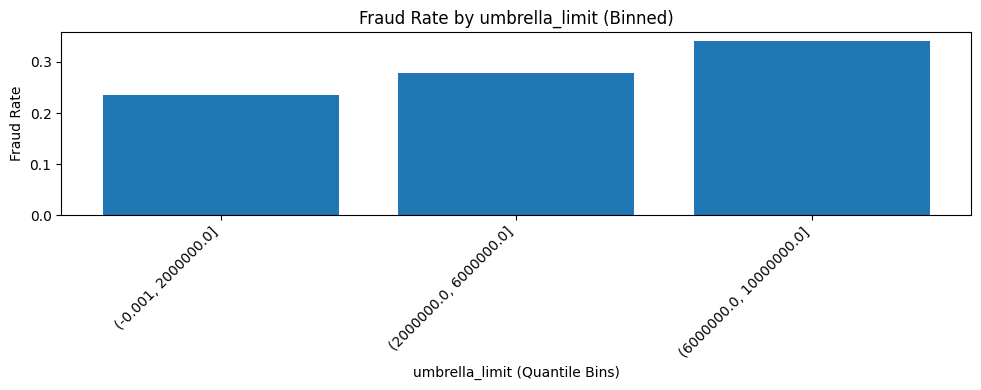

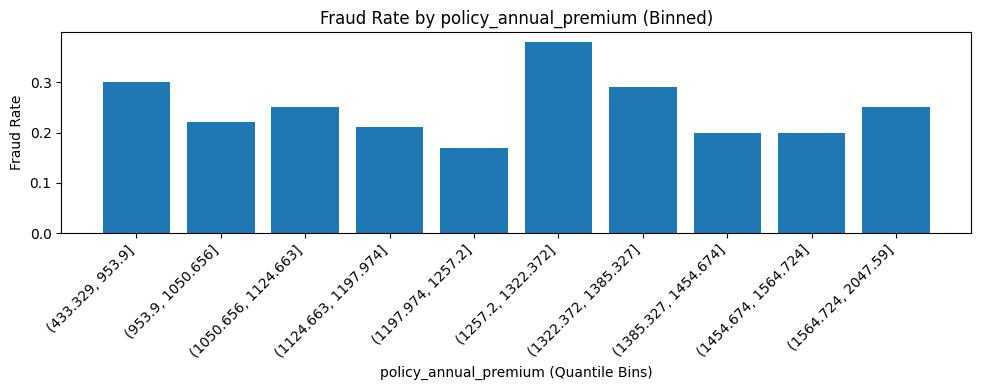

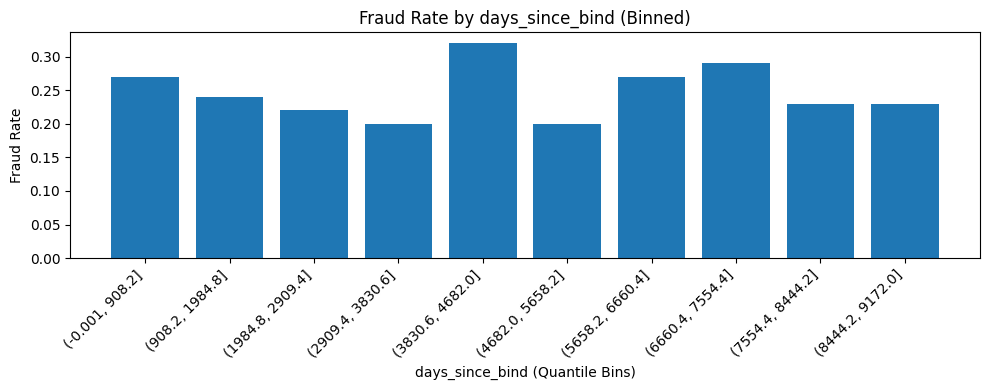

In [ ]:
# ============================================================
# step_10 CONTINUOUS FEATURE — NONLINEARITY CHECK (QUANTILE BINS)
# ============================================================
# Why:
# - Some continuous vars may have fraud signal that isn't linear.
# - We'll bin into quantiles and plot fraud rate by bin.
# - This reveals whether binning, thresholds, or interactions are better than raw input.

import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Define features to check
cont_features = [
    "umbrella_limit", 
    "policy_annual_premium", 
    "days_since_bind"
]

# --- Step 2: Bin each variable into quantiles + calculate fraud rate per bin
binned_summaries = {}

for feature in cont_features:
    # Create decile bins
    try:
        df[f"{feature}_bin"] = pd.qcut(df[feature], q=10, duplicates="drop")
        grouped = df.groupby(f"{feature}_bin", observed=True)["target"].agg(['count', 'sum'])
        grouped["fraud_rate"] = grouped["sum"] / grouped["count"]
        binned_summaries[feature] = grouped.reset_index()
    except Exception as e:
        print(f"Skipping {feature}: {e}")

# --- Step 3: Plot fraud rate per bin
import matplotlib.pyplot as plt

for feature, summary in binned_summaries.items():
    plt.figure(figsize=(10, 4))
    plt.bar(summary[f"{feature}_bin"].astype(str), summary["fraud_rate"])
    plt.title(f"Fraud Rate by {feature} (Binned)")
    plt.ylabel("Fraud Rate")
    plt.xlabel(f"{feature} (Quantile Bins)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [26]:
# ============================================================
# step_19 POLICY ANNUAL PREMIUM — FRAUD FLAG ONLY
# ============================================================
# Why:
# - Fraud peaks around 1300–1400 in earlier quantile check.
# - A binary flag captures this with minimal noise and high interpretability.

# --- Flag high-risk premium band
df["is_high_risk_premium"] = df["policy_annual_premium"].between(1300, 1400).astype(int)

# --- Fraud summary for the flag
flag_summary = (
    df.groupby("is_high_risk_premium", observed=True)["target"]
    .agg(count="count", frauds="sum")
    .assign(fraud_rate=lambda x: x["frauds"] / x["count"])
)

print("🚩 Fraud Rate for High-Risk Premium Flag:")
print(flag_summary)


🚩 Fraud Rate for High-Risk Premium Flag:
                      count  frauds  fraud_rate
is_high_risk_premium                           
0                       833     200    0.240096
1                       167      47    0.281437
